In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

In [3]:
data = load_diabetes()

print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
X, y = load_diabetes(return_X_y=True, as_frame=True)


In [5]:
print(X.info())
print("----------yy-----------")
print(y.info())

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None
----------yy-----------
<class 'pandas.Series'>
RangeIndex: 442 entries, 0 to 441
Series name: target
Non-Null Count  Dtype  
--------------  -----  
442 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB
None


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

EDA

<Axes: >

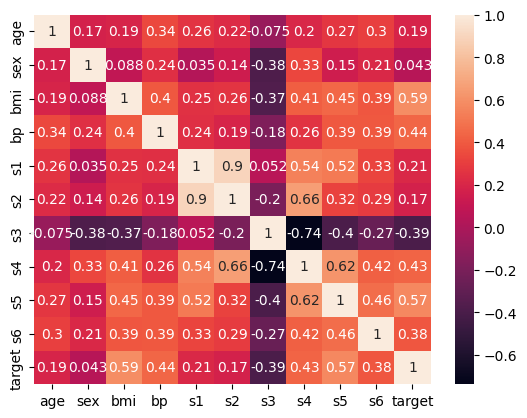

In [7]:
df = X.copy()
df['target'] = y

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)


Text(0, 0.5, 'Disease progression')

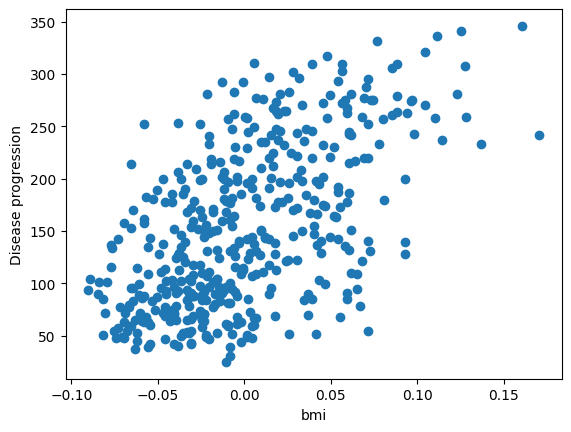

In [8]:
plt.scatter(df['bmi'], df['target'])
plt.xlabel('bmi')
plt.ylabel('Disease progression')

In [9]:
print(X_train.head())

          age       sex       bmi        bp        s1        s2        s3  \
17   0.070769  0.050680  0.012117  0.056301  0.034206  0.049416 -0.039719   
66  -0.009147  0.050680 -0.018062 -0.033213 -0.020832  0.012152 -0.072854   
137  0.005383 -0.044642  0.049840  0.097615 -0.015328 -0.016345 -0.006584   
245 -0.027310 -0.044642 -0.035307 -0.029770 -0.056607 -0.058620  0.030232   
31  -0.023677 -0.044642 -0.065486 -0.081413 -0.038720 -0.053610  0.059685   

           s4        s5        s6  
17   0.034309  0.027364 -0.001078  
66   0.071210  0.000272  0.019633  
137 -0.002592  0.017036 -0.013504  
245 -0.039493 -0.049872 -0.129483  
31  -0.076395 -0.037129 -0.042499  


In [11]:
print(X_train.describe())

              age         sex         bmi          bp          s1          s2  \
count  353.000000  353.000000  353.000000  353.000000  353.000000  353.000000   
mean     0.001442    0.000184    0.001736    0.001179   -0.000556   -0.000806   
std      0.046334    0.047644    0.047275    0.048469    0.047786    0.047631   
min     -0.107226   -0.044642   -0.089197   -0.112399   -0.108893   -0.115613   
25%     -0.030942   -0.044642   -0.032073   -0.036656   -0.035968   -0.032629   
50%      0.009016   -0.044642   -0.005128   -0.005670   -0.004321   -0.004132   
75%      0.038076    0.050680    0.032595    0.035644    0.025950    0.027183   
max      0.110727    0.050680    0.160855    0.132044    0.153914    0.198788   

               s3          s4          s5          s6  
count  353.000000  353.000000  353.000000  353.000000  
mean    -0.000989    0.000377    0.001216    0.001891  
std      0.047044    0.047790    0.047828    0.048380  
min     -0.102307   -0.076395   -0.126097   -0

In [18]:
print(y_train.head())
print(type(y_train))

17     144.0
66     150.0
137    280.0
245    125.0
31      59.0
Name: target, dtype: float64
<class 'pandas.Series'>


In [17]:
print(y_train.describe())

print(y_train)

count    353.000000
mean     153.736544
std       78.061902
min       25.000000
25%       86.000000
50%      142.000000
75%      214.000000
max      346.000000
Name: target, dtype: float64
17     144.0
66     150.0
137    280.0
245    125.0
31      59.0
       ...  
106    134.0
270    202.0
348    148.0
435     64.0
102    302.0
Name: target, Length: 353, dtype: float64


Skapar 3 olika modeller för att utvärdera vilken som är bäst med korsvalidering

In [21]:
lin_reg = LinearRegression()

scores_lr = cross_validate(lin_reg, X_train, y_train, cv=3, scoring='neg_mean_squared_error')['test_score']
print(f'RMSE for each iteration: {np.sqrt(-scores_lr)}')
print(f'RMSE: {np.sqrt(np.mean(-scores_lr))}')

RMSE for each iteration: [53.31283683 53.16309571 59.79731897]
RMSE: 55.51063763526888


In [22]:
lasso = Lasso()
hyper_param_lasso = {'alpha' : (0.01, 1, 2, 5, 10)}
lasso_reg = GridSearchCV(lasso, hyper_param_lasso, cv=5)
lasso_reg.fit(X_train, y_train)

print(lasso_reg.best_params_)


{'alpha': 0.01}
